## Run a pipeline

### Minimal Pipeline Execution: Runs in just **3 lines of code**

```python
from paidiverpy.pipeline import Pipeline
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")
pipeline.run()
```

### This is the configuration file:


```yaml
general:
  sample_data: "benthic_ifdo"
  output_path: "./output"
  n_jobs: 8
  sampling:
    - mode: "fixed"
      params:
        value: 5
  convert:
    - mode: "bits"
      params:
        output_bits: 8
steps:
  - colour:
      name: "colour_correction"
      mode: "grayscale"

  - sampling:
      name: "datetime"
      mode: "datetime"
      params:
        min: "2016-05-11 04:14:00"
        max: "2016-05-11 09:27:00"

  - colour:
      name: "colour_correction"
      mode: "gaussian_blur"
      params:
        sigma: 1.0

  - colour:
      name: "sharpen"
      mode: "sharpen"
      params:
        alpha: 1.5
        beta: -0.5

  - colour:
      name: "contrast"
      mode: "contrast"
```

### Sample data

This configuration file uses a part of our example data:

```yaml
general:
  sample_data: "benthic_ifdo"
```

In this case, it will download the data automatically. But you can also do it manually:

In [1]:
from paidiverpy.utils.data import PaidiverpyData

data = PaidiverpyData()
data.load("benthic_ifdo")

{'input_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/images',
 'metadata_path': '/home/tobfer/.paidiverpy_cache/benthic_ifdo/metadata/metadata_benthic_ifdo.json',
 'metadata_type': 'IFDO',
 'image_type': 'JPG'}

## Running the code

In [2]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

In [3]:
pipeline = Pipeline(config_file_path="../config_files/config_benthic.yml")

In [4]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [5]:
# See the pipeline steps in json format
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'name': 'raw',
   'step_name': 'open',
   'sample_data': 'benthic_csv',
   'input_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/images'),
   'metadata_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv'),
   'metadata_type': 'CSV_FILE',
   'image_type': 'PNG',
   'append_data_to_metadata': '/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv',
   'is_remote': False,
   'output_is_remote': False,
   'output_path': PosixPath('output'),
   'n_jobs': 16,
   'client': None,
   'track_changes': True,
   'rename': None,
   'sampling': [{'name': 'sampling',
     'step_name': 'sampling',
     'mode': 'fixed',
     'test': False,
     'params': {'value': 20, 'raise_error': False}}],
   'convert': None}),
 ('colour_correction',
  paidiverpy.colour_layer.colour_layer.ColourLayer,
  {'name': 'colour_correction',
   'step_name': 'colour',
   'mode': '

In [6]:
pipeline.get_metadata()

,ID,image-filename,XResolution,YResolution,ExposureTime,FNumber,ISO,image-datetime,MaxApertureValue,WhiteBalance,...,speed_of_sound_m_s,temperature_c,positioning_ok,attitude_ok,depth_ok,altitude_ok,X,phototime,flag,point
0,430.0,20180611041421.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:21,2.828427,FLASH,...,1545.388,1.5059,1,1,1,1,NaN,2018-06-11 04:14:21,0,POINT (-153.60531587 11.25172554)
1,431.0,20180611041431.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:31,2.828427,FLASH,...,1545.447,1.5236,1,1,1,1,NaN,2018-06-11 04:14:31,0,POINT (-153.60531372 11.25171832)
2,432.0,20180611041441.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:41,2.828427,FLASH,...,1545.452,1.5234,1,1,1,1,NaN,2018-06-11 04:14:41,0,POINT (-153.60531259 11.2517135)
3,433.0,20180611041451.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:14:51,2.828427,FLASH,...,1545.363,1.4911,1,1,1,1,NaN,2018-06-11 04:14:51,0,POINT (-153.60531313 11.25170837)
4,434.0,20180611041501.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:01,2.828427,FLASH,...,1545.324,1.4747,1,1,1,1,NaN,2018-06-11 04:15:01,0,POINT (-153.60531414 11.25170299)
5,435.0,20180611041511.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:11,2.828427,FLASH,...,1545.298,1.4635,1,1,1,1,NaN,2018-06-11 04:15:11,0,POINT (-153.60531664 11.25169768)
6,436.0,20180611041521.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:21,2.828427,FLASH,...,1545.315,1.4697,1,1,1,1,NaN,2018-06-11 04:15:21,0,POINT (-153.6053176 11.25169125)
7,437.0,20180611041531.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:31,2.828427,FLASH,...,1545.326,1.4727,1,1,1,1,NaN,2018-06-11 04:15:31,0,POINT (-153.60532046 11.25168357)
8,438.0,20180611041541.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:41,2.828427,FLASH,...,1545.266,1.4532,1,1,1,1,NaN,2018-06-11 04:15:41,0,POINT (-153.60532129 11.25167559)
9,439.0,20180611041551.png,300.0,300.0,0.016667,8.0,200.0,2018-06-11 04:15:51,2.828427,FLASH,...,1545.263,1.4512,1,1,1,1,NaN,2018-06-11 04:15:51,0,POINT (-153.60532147 11.25166737)


In [7]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:30:13 | Processing images using 16 cores


☁ paidiverpy ☁  |       INFO | 2025-03-06 10:30:13 | Running step 0: raw - OpenLayer


[                                        ] | 0% Completed | 928.83 us

[                                        ] | 0% Completed | 106.61 ms

[########################                ] | 60% Completed | 213.47 ms

...

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:30:15 | Running step 6: contrast - ColourLayer


[                                        ] | 0% Completed | 986.95 us

[#####################                   ] | 54% Completed | 111.59 ms

[########################################] | 100% Completed | 270.39 ms

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:30:16 | Step 6 completed


Step: raw
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Image: dask.array<getitem, shape=(128, 128, 4), dtype=uint8, chunksize=(128, 128, 4), chunktype=numpy.ndarray>
Step: colour_correction
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndarray>
Image: dask.array<array, shape=(128, 128), dtype=uint8, chunksize=(128, 128), chunktype=numpy.ndar
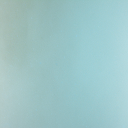
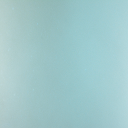
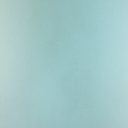
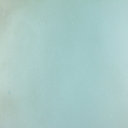
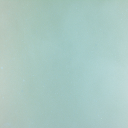
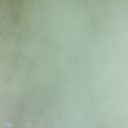
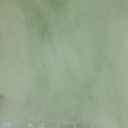
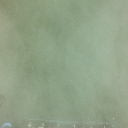
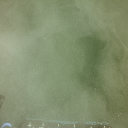
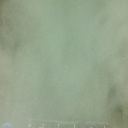
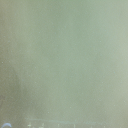
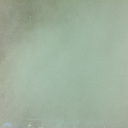
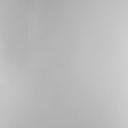
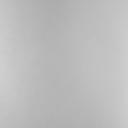
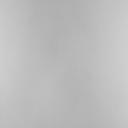
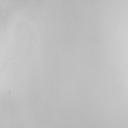
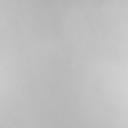
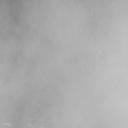
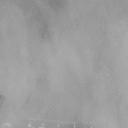
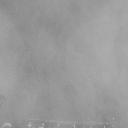
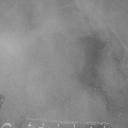
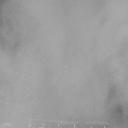
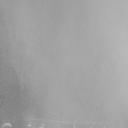
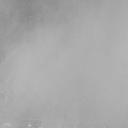
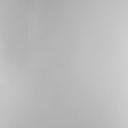
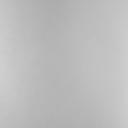
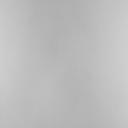
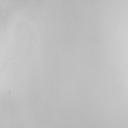
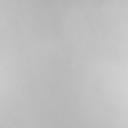
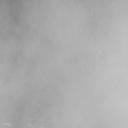
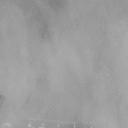
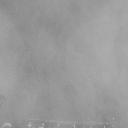
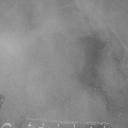
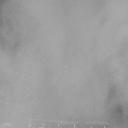
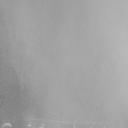
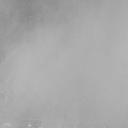
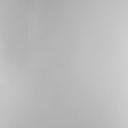
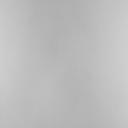
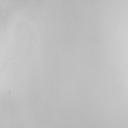
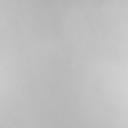
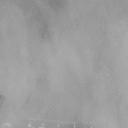
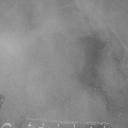
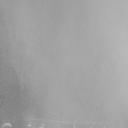
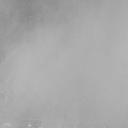
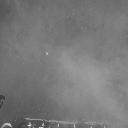
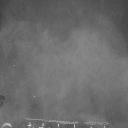
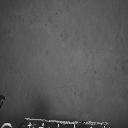
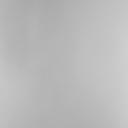
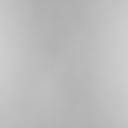
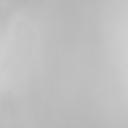
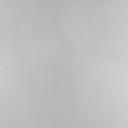
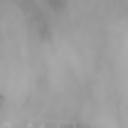
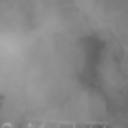
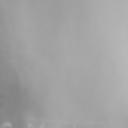
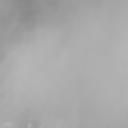
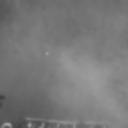
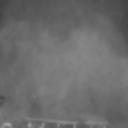
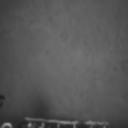
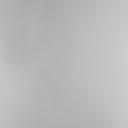
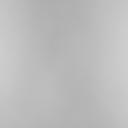
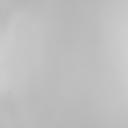
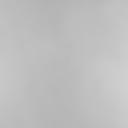
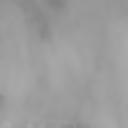
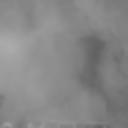
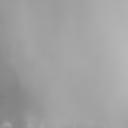
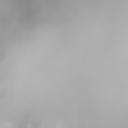
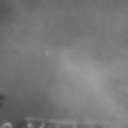
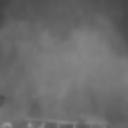
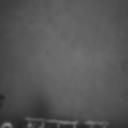
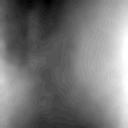
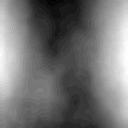
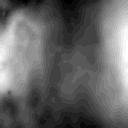
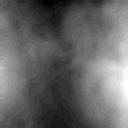
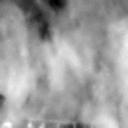
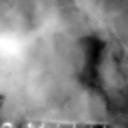
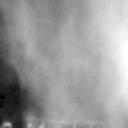
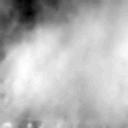
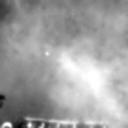
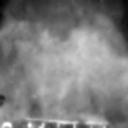
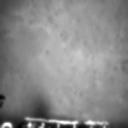

In [8]:
# See the images output
pipeline.images


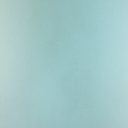
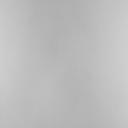
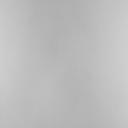
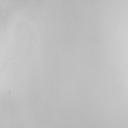
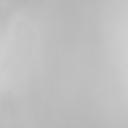
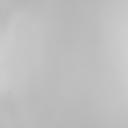
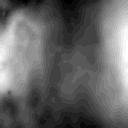

In [9]:
pipeline.images.show(image_number=2)

# Export Images to file

In [10]:
pipeline.save_images(image_format="png")

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:30:16 | Saving images from step: last


☁ paidiverpy ☁  |       INFO | 2025-03-06 10:30:16 | Saving images using Dask


[                                        ] | 0% Completed | 943.74 us

[########################################] | 100% Completed | 106.79 ms

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:30:16 | Images are saved to: output
